In [1]:
import os

PI = "pi@192.168.11.89"
DEST = "/Users/Marek/Documents/raspberry/netatmo"

FILES = [
    "/home/pi/teplota_pradelna.csv",
    "/home/pi/teplota_log.csv",
    "/home/pi/netatmo/climate.log",
    "/home/pi/netatmo/netatmo_climate.csv", 
]

scp_cmd = "scp " + " ".join(f"{PI}:{f}" for f in FILES) + f' "{DEST}"'
os.system(scp_cmd)


0

In [10]:
# import pandas as pd
#  timezone-aware
# start_tz = pd.Timestamp("2026-09-18 10:00:00", tz="Europe/Prague")
# end_tz   = pd.Timestamp("2026-09-20 8:00:00", tz="Europe/Prague")
#  timezone-naive
# start_naive = start_tz.tz_localize(None)
# end_naive   = end_tz.tz_localize(None)

In [ ]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# --- GLOBÁLNÍ PROMĚNNÉ ---
start_tz = None
end_tz = None
start_naive = None
end_naive = None

# --- POSUVNÍK ---
slider = widgets.IntSlider(
    value=22,
    min=1,
    max=48,
    step=1,
    description="Kolik hodin:",
    continuous_update=False
)

# --- DATUM END ---
import datetime

end_date = widgets.DatePicker(
    description="End datum:",
    disabled=False,
    value=datetime.date.today()
)


# --- HODINA END ---
now = datetime.datetime.now()
next_hour = (now.hour + 1) % 24

end_hour = widgets.Dropdown(
    options=[f"{h:02d}" for h in range(24)],
    value=f"{next_hour:02d}",
    description="End hodina:"
)

# --- TLAČÍTKO ---
button = widgets.Button(
    description="Vypočítat",
    button_style="success"
)

# --- OUTPUT BOX ---
out = widgets.Output()

display(slider, end_date, end_hour, button, out)

def compute_times(hours_back, end_date_value, end_hour_value):
    end_tz = pd.Timestamp(
        year=end_date_value.year,
        month=end_date_value.month,
        day=end_date_value.day,
        hour=int(end_hour_value),
        minute=0,
        second=0,
        tz="Europe/Prague"
    )

    start_tz = end_tz - pd.Timedelta(hours=hours_back)

    start_naive = start_tz.tz_localize(None)
    end_naive   = end_tz.tz_localize(None)

    return start_tz, end_tz, start_naive, end_naive

def on_button_click(b):
    global start_tz, end_tz, start_naive, end_naive

    with out:
        out.clear_output()

        if end_date.value is None:
            print("❗ Vyber prosím end datum.")
            return

        # ULOŽENÍ DO GLOBÁLNÍCH PROMĚNNÝCH
        start_tz, end_tz, start_naive, end_naive = compute_times(
            slider.value,
            end_date.value,
            end_hour.value
        )

        print("start_tz:   ", start_tz)
        print("start_naive:", start_naive)
        print("end_tz:     ", end_tz)
        print("end_naive:  ", end_naive)
        print("-" * 40)

button.on_click(on_button_click)


IntSlider(value=22, continuous_update=False, description='Kolik hodin:', max=48, min=1)

DatePicker(value=datetime.date(2026, 9, 28), description='End datum:', step=1)

Dropdown(description='End hodina:', index=8, options=('00', '01', '02', '03', '04', '05', '06', '07', '08', '0…

Button(button_style='success', description='Vypočítat', style=ButtonStyle())

Output()

## Zobrazení poslední hodiny teplota_log.csv

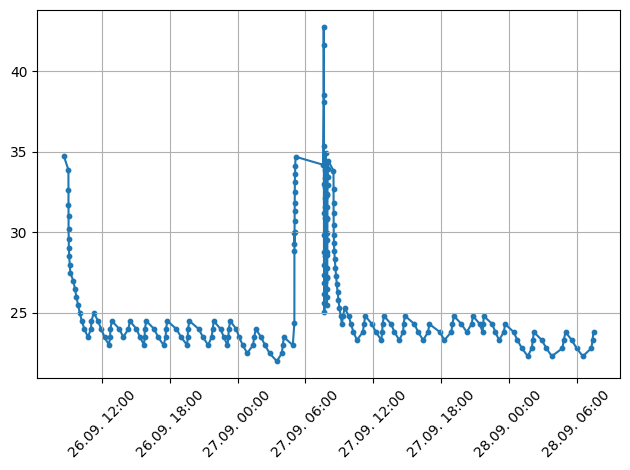

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import zoneinfo

ax = plt.gca()
ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%d.%m. %H:%M', tz=zoneinfo.ZoneInfo("Europe/Prague"))
)
plt.xticks(rotation=45)

df = pd.read_csv("/Users/Marek/Documents/raspberry/netatmo/teplota_log.csv", header=None, names=["Time", "Value"])
df["Time"] = (
    pd.to_datetime(df["Time"], errors="coerce") 
    .dt.tz_localize("Europe/Prague") # ← DŮLEŽITÉ 
)
              
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
df = df.dropna().sort_values("Time").drop_duplicates("Time")

df_plot = df[df["Time"] >= df["Time"].max() - pd.Timedelta(hours=48)]

plt.plot(df_plot["Time"], df_plot["Value"])
plt.scatter(df_plot["Time"], df_plot["Value"], s=10)
plt.grid()
plt.tight_layout()
plt.show()


In [4]:
 
df.tail(10)



,Time,Value
33621,2026-09-28 03:48:45+02:00,22.312
33622,2026-09-28 04:45:24+02:00,22.812
33623,2026-09-28 04:51:57+02:00,23.312
33624,2026-09-28 05:01:36+02:00,23.812
33625,2026-09-28 05:34:45+02:00,23.312
33626,2026-09-28 06:00:16+02:00,22.812
33627,2026-09-28 06:33:24+02:00,22.312
33628,2026-09-28 07:19:18+02:00,22.812
33629,2026-09-28 07:24:57+02:00,23.312
33630,2026-09-28 07:30:14+02:00,23.812


## Vytvoření df_netatmo ze souboru netatmo_data.csv

In [5]:
import pandas as pd

# Cesta k souboru
path = "/Users/Marek/Documents/raspberry/netatmo/netatmo_climate.csv"

# Načtení dat - tentokrát bez skiprows, protože data začínají hned
df_netatmo = pd.read_csv(path)

# 1) převod z UNIX sekund na datetime
df_netatmo["timestamp"] = ( 
    pd.to_datetime(df_netatmo["timestamp"], unit="s", utc=True) 
    .dt.tz_convert("Europe/Prague") 
)

# 2) pokud chceš formátovaný textový sloupec
df_netatmo["timestamp_str"] = df_netatmo["timestamp"].dt.strftime("%d.%m.%Y %H:%M:%S")


# Ukázka dat
df_netatmo.tail(10)


,timestamp,temp_indoor,temp_outdoor,setpoint,boiler,pressure,timestamp_str
57574,2026-09-28 06:10:16+02:00,22.0,6.6,22.0,False,1025.4,28.09.2026 06:10:16
57575,2026-09-28 06:15:12+02:00,22.0,6.6,22.0,False,1025.3,28.09.2026 06:15:12
57576,2026-09-28 06:20:16+02:00,22.0,6.6,22.0,False,1025.4,28.09.2026 06:20:16
57577,2026-09-28 06:25:11+02:00,22.0,6.5,22.0,False,1025.4,28.09.2026 06:25:11
57578,2026-09-28 06:30:26+02:00,22.0,6.5,22.0,False,1025.4,28.09.2026 06:30:26
57579,2026-09-28 06:35:11+02:00,22.0,6.5,22.0,False,1025.4,28.09.2026 06:35:11
57580,2026-09-28 06:45:11+02:00,22.0,6.5,22.0,False,1025.4,28.09.2026 06:45:11
57581,2026-09-28 07:10:13+02:00,22.0,6.4,22.0,False,1025.5,28.09.2026 07:10:13
57582,2026-09-28 07:25:11+02:00,22.0,6.3,22.0,False,1025.6,28.09.2026 07:25:11
57583,2026-09-28 07:35:11+02:00,22.0,6.3,22.0,False,1025.6,28.09.2026 07:35:11


### Výpočet boiler_water_2 z temp_outdoor v df_netatmo, který byl vytvořen výše

In [6]:
import pandas as pd


# 3) Nová křivka podle bodů A(-20,15) a B(40,33) 
def hokejka3(temp_in):
    if temp_in <= 10:
        return -0.233333 * temp_in + 35.333333
    else:
        return 33

# Sloupec Boiler_water
# df_netatmo["Boiler_water"] = df_netatmo["temp_outdoor"].apply(hokejka)

# Nový sloupec Boiler_water_2
df_netatmo["Boiler_water_2"] = df_netatmo["temp_outdoor"].apply(hokejka3)

# Ukázka posledních 10 řádků
df_netatmo.tail(10)

html_table1 = (
    df_netatmo.tail(10)
    .style.set_table_attributes('class="table table-hover table-bordered"')
    .set_properties(**{'text-align': 'center'})
    .background_gradient(cmap="coolwarm")
    .to_html()
)


## Nový soubor raspberry teplota_log.csv

Počet NaT: 0
Typ time_local: datetime64[ns, Europe/Prague]


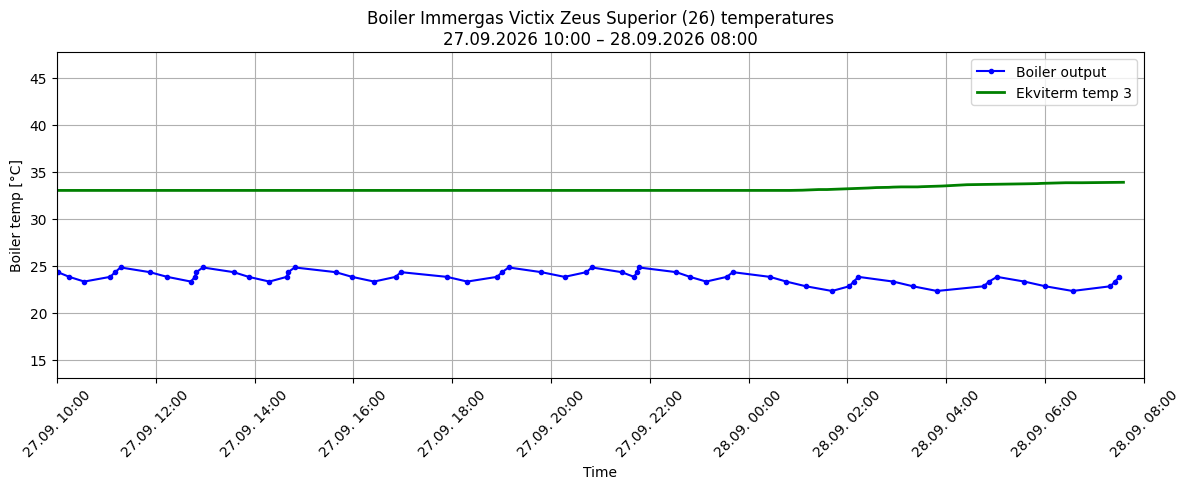

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import zoneinfo

# ---------------------------------------------------------
# ČASOVÉ OKNO
# ---------------------------------------------------------
# start_tz = pd.Timestamp("2026-09-15 10:00:00", tz="Europe/Prague")
# end_tz   = pd.Timestamp("2026-09-21 09:00:00", tz="Europe/Prague")

start_naive = start_tz.tz_localize(None)
end_naive   = end_tz.tz_localize(None)

plt.figure(figsize=(12, 5))
ax = plt.gca()

# ---------------------------------------------------------
# 1) KOTEL
# ---------------------------------------------------------
df["Time"] = pd.to_datetime(
    df["Time"],
    errors="coerce"
)

# odstranění neplatných řádků
df = df.dropna(subset=["Time", "Value"])

if df["Time"].dt.tz is None:
    df["Time"] = df["Time"].dt.tz_localize("Europe/Prague")
else:
    df["Time"] = df["Time"].dt.tz_convert("Europe/Prague")

ax.plot(
    df["Time"],
    df["Value"],
    marker=".",
    color="blue",
    label="Boiler output"
)

# ---------------------------------------------------------
# 2) NETATMO
# ---------------------------------------------------------
# timestamp už obsahuje datetime

df_netatmo["time_local"] = pd.to_datetime(
    df_netatmo["timestamp"],
    errors="coerce"
)

# odstranění problematických řádků
df_netatmo = df_netatmo.dropna(
    subset=["time_local", "Boiler_water_2"]
)

print("Počet NaT:", df_netatmo["time_local"].isna().sum())
print("Typ time_local:", df_netatmo["time_local"].dtype)

ax.plot(
    df_netatmo["time_local"],
    df_netatmo["Boiler_water_2"],
    color="green",
    linewidth=2,
    label="Ekviterm temp 3"
)

# ---------------------------------------------------------
# 3) ČASOVÉ OKNO
# ---------------------------------------------------------
ax.set_xlim(start_tz, end_tz)

# ---------------------------------------------------------
# 4) FORMÁT OSY X
# ---------------------------------------------------------
ax.xaxis.set_major_formatter(
    mdates.DateFormatter(
        "%d.%m. %H:%M",
        tz=zoneinfo.ZoneInfo("Europe/Prague")
    )
)

plt.xticks(rotation=45)

plt.title(
    f"Boiler Immergas Victix Zeus Superior (26) temperatures\n"
    f"{start_naive:%d.%m.%Y %H:%M} – {end_naive:%d.%m.%Y %H:%M}"
)

ax.set_xlabel("Time")
ax.set_ylabel("Boiler temp [°C]")

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Import souboru Climate.csv

In [8]:
import pandas as pd

df_climate = pd.read_csv(path)

df_climate["time_local"] = (
    pd.to_datetime(df_climate["timestamp"], unit="s", utc=True)
    .dt.tz_convert("Europe/Prague")
)

df_climate["time_local_str"] = df_climate["time_local"].dt.strftime("%d.%m.%Y %H:%M:%S")

df_climate.tail(10)





,timestamp,temp_indoor,temp_outdoor,setpoint,boiler,pressure,time_local,time_local_str
57574,1.790569e+09,22.0,6.6,22.0,False,1025.4,2026-09-28 06:10:16+02:00,28.09.2026 06:10:16
57575,1.790569e+09,22.0,6.6,22.0,False,1025.3,2026-09-28 06:15:12+02:00,28.09.2026 06:15:12
57576,1.790569e+09,22.0,6.6,22.0,False,1025.4,2026-09-28 06:20:16+02:00,28.09.2026 06:20:16
57577,1.790570e+09,22.0,6.5,22.0,False,1025.4,2026-09-28 06:25:11+02:00,28.09.2026 06:25:11
57578,1.790570e+09,22.0,6.5,22.0,False,1025.4,2026-09-28 06:30:26+02:00,28.09.2026 06:30:26
57579,1.790570e+09,22.0,6.5,22.0,False,1025.4,2026-09-28 06:35:11+02:00,28.09.2026 06:35:11
57580,1.790571e+09,22.0,6.5,22.0,False,1025.4,2026-09-28 06:45:11+02:00,28.09.2026 06:45:11
57581,1.790572e+09,22.0,6.4,22.0,False,1025.5,2026-09-28 07:10:13+02:00,28.09.2026 07:10:13
57582,1.790573e+09,22.0,6.3,22.0,False,1025.6,2026-09-28 07:25:11+02:00,28.09.2026 07:25:11
57583,1.790574e+09,22.0,6.3,22.0,False,1025.6,2026-09-28 07:35:11+02:00,28.09.2026 07:35:11


## Setpoint a teplota kotle

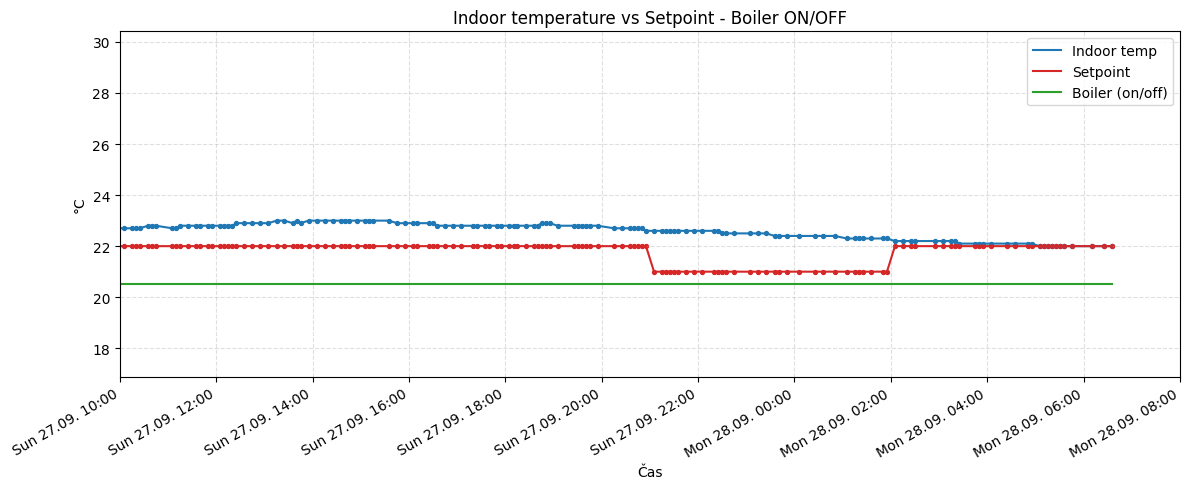

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Převod timestamp → datetime + posun o 1 hodinu
df_climate["time"] = pd.to_datetime(df_climate["timestamp"], unit="s") + pd.to_timedelta(1, "h")

# --- ČASOVÉ OKNO (naivní, protože df_climate["time"] je také naivní) ---


# -----------------------------
# GRAF
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 5))

# Indoor temp
ax.plot(df_climate["time"], df_climate["temp_indoor"], label="Indoor temp",
        color="tab:blue", linewidth=1.5)
ax.scatter(df_climate["time"], df_climate["temp_indoor"], s=8, color="tab:blue")

# Setpoint
ax.plot(df_climate["time"], df_climate["setpoint"], label="Setpoint",
        color="tab:red", linewidth=1.5)
ax.scatter(df_climate["time"], df_climate["setpoint"], s=8, color="tab:red")

# Boiler (0/1) posunutý nahoru
ax.plot(df_climate["time"], df_climate["boiler"] + 20.5,
        label="Boiler (on/off)", color="tab:green", linewidth=1.5)

# --- ČASOVÉ OKNO ---
ax.set_xlim(start_naive, end_naive)

ax.set_title("Indoor temperature vs Setpoint - Boiler ON/OFF")
ax.set_xlabel("Čas")
ax.set_ylabel("°C")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend()

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %d.%m. %H:%M'))
fig.autofmt_xdate()

plt.tight_layout()
plt.show()




In [11]:
from IPython.display import Markdown, display

df_net = df_netatmo.sort_values("timestamp")

# poslední start (False → True)
starts = (df_net["boiler"] == True) & (df_net["boiler"].shift(1) == False)
last_start = df_net[starts].iloc[-1]["timestamp_str"]

# poslední stop (True → False)
stops = (df_net["boiler"] == False) & (df_net["boiler"].shift(1) == True)
last_stop = df_net[stops].iloc[-1]["timestamp_str"]

# poslední záznam (timestamp)
last_timestamp = df_net.iloc[-1]["timestamp_str"]

# poslední venkovní teplota
last_temp_outdoor = df_net.iloc[-1]["temp_outdoor"]

# poslední tlak vzduchu
last_pressure = df_net.iloc[-1]["pressure"]

# 1) Seřadíme start/stop podle času (nejstarší první)
if last_start <= last_stop:
    kotel_text = (
        f"# 🔥 Poslední start kotle: **{last_start}**\n"
        f"# ❄️ Poslední odstavení kotle: **{last_stop}**\n"
    )
else:
    kotel_text = (
        f"# ❄️ Poslední odstavení kotle: **{last_stop}**\n"
        f"# 🔥 Poslední start kotle: **{last_start}**\n"
    )

# 2) Nejprve vypíšeme log, teplotu, tlak
text = (
    f"# 🕒 Poslední záznam v logu: **{last_timestamp}**\n"
    f"# 🌡️ Poslední venkovní teplota: **{last_temp_outdoor:.1f} °C**\n"
    f"# 🌬️ Poslední tlak vzduchu: **{last_pressure:.1f} hPa**\n"
)

# 3) A až POTOM vypíšeme obě hodnoty kotle v seřazeném pořadí
text += kotel_text

display(Markdown(text))




# 🕒 Poslední záznam v logu: **27.09.2026 15:05:08**
# 🌡️ Poslední venkovní teplota: **20.5 °C**
# 🌬️ Poslední tlak vzduchu: **1025.6 hPa**
# 🔥 Poslední start kotle: **27.09.2026 05:05:11**
# ❄️ Poslední odstavení kotle: **27.09.2026 08:35:10**


## Venkovní teplota a ekviterma

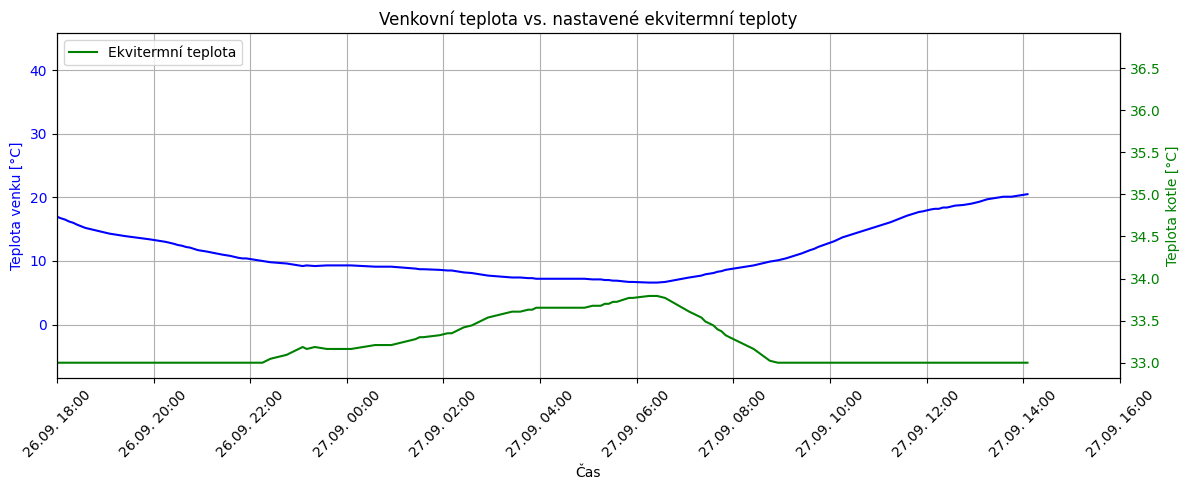

In [12]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Posun času o 1 hodinu
df_netatmo["timestamp_shifted"] = df_netatmo["timestamp"] + pd.to_timedelta(1, "h")

fig, ax = plt.subplots(figsize=(12, 5))

# Hlavní osa – venkovní teplota
ax.plot(df_netatmo["timestamp_shifted"], df_netatmo["temp_outdoor"],
        color="blue", label="Teplota venku")
ax.set_ylabel("Teplota venku [°C]", color="blue")
ax.tick_params(axis="y", labelcolor="blue")

# Vedlejší osa – teplota kotle
ax2 = ax.twinx()
ax2.plot(df_netatmo["timestamp_shifted"], df_netatmo["Boiler_water_2"],
         color="green", label="Ekvitermní teplota")
ax2.set_ylabel("Teplota kotle [°C]", color="green")
ax2.tick_params(axis="y", labelcolor="green")

# Titulek a popisky
ax.set_title("Venkovní teplota vs. nastavené ekvitermní teploty")
ax.set_xlabel("Čas")

# Formátování osy X
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m. %H:%M'))
ax.tick_params(axis='x', rotation=45)
ax.set_xlim(start_naive, end_naive)

# Legenda
ax2.legend(loc="upper left")

ax.grid(True)
fig.tight_layout()
plt.show()




## Programování ekvitermních křivek

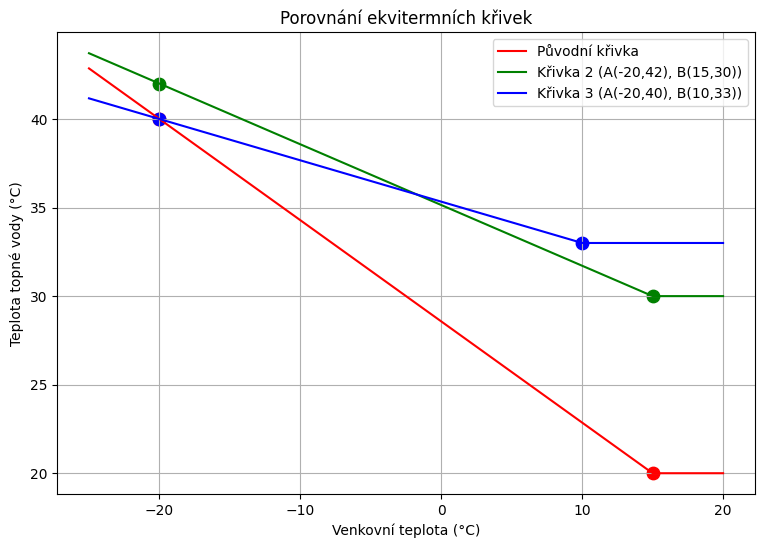

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Původní křivka
def hokejka(temp_in):
    if temp_in <= 15:
        return -0.571428 * temp_in + 28.5714
    else:
        return 20

# 2) Druhá křivka (A(-20,42), B(15,30) – tvoje stará verze)
def hokejka2(temp_in):
    if temp_in <= 15:
        return -0.342857 * temp_in + 35.143
    else:
        return 30

# 3) Nová křivka podle bodů A(-20,40) a B(10,33) 
def hokejka3(temp_in):
    if temp_in <= 10:
        return -0.233333 * temp_in + 35.333333
    else:
        return 33

# Data pro graf
temps_in = np.linspace(-25, 20, 200)
temps_out_1 = [hokejka(t) for t in temps_in]
temps_out_2 = [hokejka2(t) for t in temps_in]
temps_out_3 = [hokejka3(t) for t in temps_in]

# Vykreslení
plt.figure(figsize=(9, 6))
plt.plot(temps_in, temps_out_1, label="Původní křivka", color="red")
plt.plot(temps_in, temps_out_2, label="Křivka 2 (A(-20,42), B(15,30))", color="green")
plt.plot(temps_in, temps_out_3, label="Křivka 3 (A(-20,40), B(10,33))", color="blue")

# Body původní křivky
plt.scatter([-20, 15], [40, 20], color="red", s=80)

# Body křivky 2
plt.scatter([-20, 15], [42, 30], color="green", s=80)

# Body křivky 3
plt.scatter([-20, 10], [40, 33], color="blue", s=80)

plt.title("Porovnání ekvitermních křivek")
plt.xlabel("Venkovní teplota (°C)")
plt.ylabel("Teplota topné vody (°C)")
plt.grid(True)
plt.legend()

plt.show()


## Tlak vzduchu z Climate

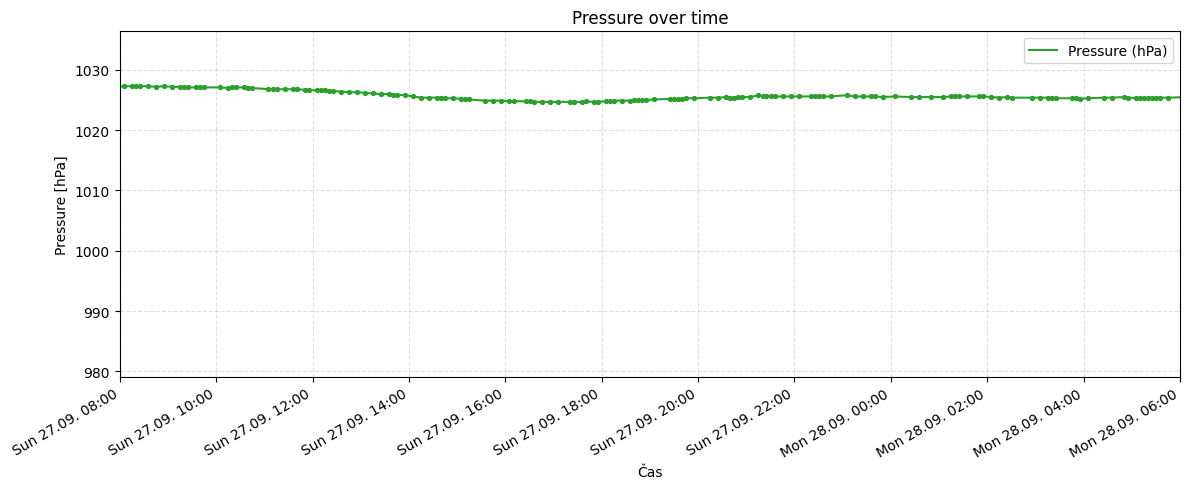

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# -----------------------------
# GRAF TLAKU
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_climate["time"], df_climate["pressure"],
        label="Pressure (hPa)", color="tab:green", linewidth=1.5)

ax.scatter(df_climate["time"], df_climate["pressure"], s=8, color="tab:green")

ax.set_xlim((start_tz), end_tz)
ax.set_title("Pressure over time")
ax.set_xlabel("Čas")
ax.set_ylabel("Pressure [hPa]")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend()

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %d.%m. %H:%M'))
fig.autofmt_xdate()

plt.tight_layout()
plt.show()



## Teplota v prádelně

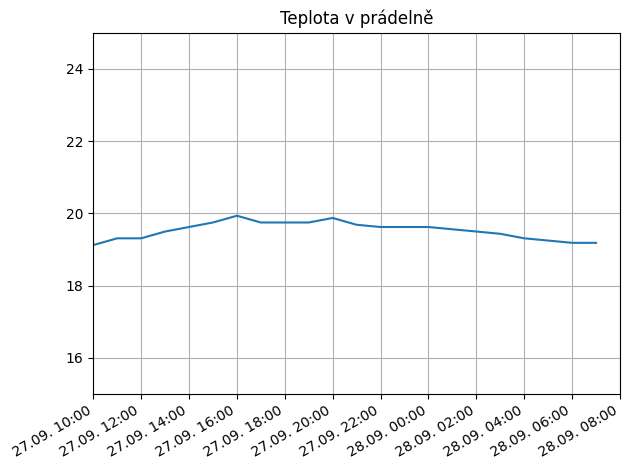

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# import mplcursors

df_pradelna = pd.read_csv("/Users/Marek/Documents/raspberry/netatmo/teplota_pradelna.csv", header=None, names=["cas", "tepl"])
# df_pradelna["cas"] = pd.to_datetime(df_pradelna["cas"], errors="coerce")
df_pradelna["cas"] = pd.to_datetime(df_pradelna["cas"], format="%Y-%m-%d %H:%M:%S", errors="coerce")
df_pradelna["tepl"] = pd.to_numeric(df_pradelna["tepl"], errors="coerce")
df_pradelna = df_pradelna.dropna().sort_values("cas").drop_duplicates("cas")

fig, ax = plt.subplots()

ax.set_ylim(15, 25)
ax.set_title("Teplota v prádelně")

ax.plot(df_pradelna["cas"], df_pradelna["tepl"], linestyle="-", marker=None)
# ax.plot(df_pradelna["cas"], df_pradelna["tepl"], marker=".")
# ax.scatter(df_pradelna["cas"], df_pradelna["tepl"], s=5)
ax.set_xlim(start_naive, end_naive)

ax.grid()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m. %H:%M'))
fig.autofmt_xdate()

plt.tight_layout()
# mplcursors.cursor(hover=True)
plt.show()


